## Annotation Analysis

Two annotators annotated part 3 of the dataset. We use Cohen's Kappa to compute the agreement between these two annotators. 

In [6]:
import os
import re
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.metrics import cohen_kappa_score
from augment_sheet import merge_excel_files, sheets_to_dataframe

# annotated data directory path
annotated_data_dir = Path('annotated_data')

# match the name of files in the directory with pattern 'part_[0-9].xlsx' using re
file_pattern = re.compile(r'.*part_[0-9]+\.xlsx')
files = [annotated_data_dir / f for f in os.listdir(annotated_data_dir) if file_pattern.match(f)]

# merge excel files
# merge_excel_files(files, 'mcmaster_reddit.xlsx')

# read all sheets from the merged excel file into a DataFrame
df_all = sheets_to_dataframe(annotated_data_dir / 'mcmaster_reddit.xlsx')

# read sheet named 'part_3_[AB]' under annotated_data_dir into DataFrame
df_part_3_A = pd.read_excel(annotated_data_dir / 'mcmaster_reddit_part_3_A.xlsx')
df_part_3_B = pd.read_excel(annotated_data_dir / 'mcmaster_reddit_part_3_B.xlsx')

# compute Cohen's kappa score for the two annotators on the 'part_3_A' sheet
ck_score = cohen_kappa_score(df_part_3_A['label'].values, df_part_3_B['label'].values)
print(f"Cohen's Kappa score: {ck_score:.4f}")


Cohen's Kappa score: 0.4265


Next, we determine the ground truth labels for the dataset through adjudication: we look at where the annotators for part 3 disagree and assign the groud truth label to our best understanding of the datapoints (posts). We also assign/validate labels to datapoints having invlaid labels (e.g.,missing values, labels in lower case, and ","). 

See files in the dirctory `annotated_data`:
- `mcmaster_reddit_part_[1-7].xlsx` are the data with ground truth labels and
- `mcmaster_reddit_part_3_[AB].xlsx` are data labeled by two annotators.


### Label Distribution Visualization

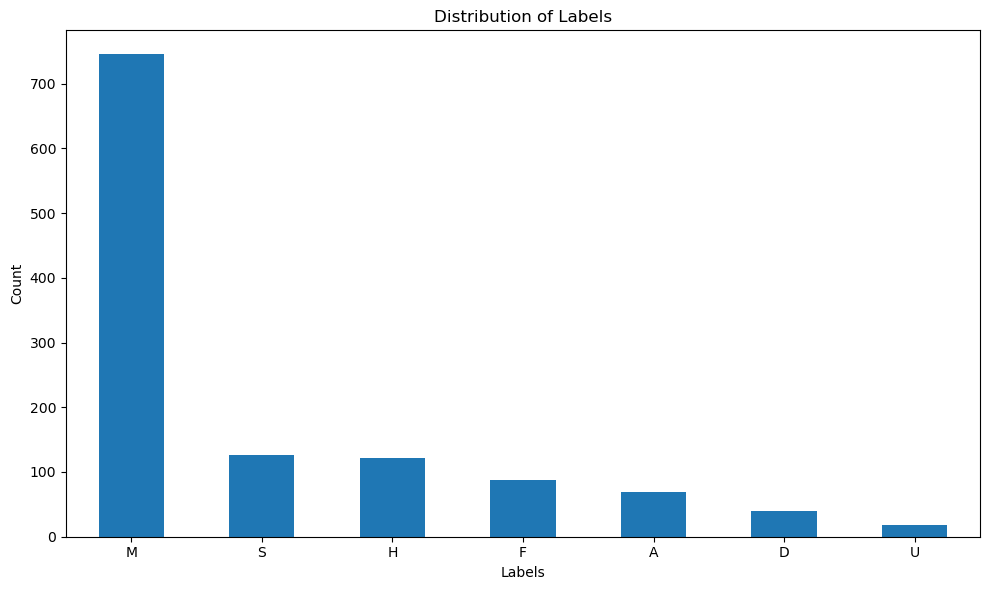

In [12]:
import matplotlib.pyplot as plt

# plot the distribution of labels in the merged DataFrame
plt.figure(figsize=(10, 6))
df_all['label'].value_counts().plot(kind='bar')
plt.title('Distribution of Labels')
plt.xlabel('Labels')
plt.xticks(rotation=0)
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('label_distribution.png')
plt.show()

## Dataset Preparation

**Data Split**
- Train: 60%
- Validation: 20%
- Test: 20%

In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import TensorDataset, DataLoader

# Load data
data = pd.read_csv('annotated_data/dataset.csv')

# Drop the rows with missing labels
data = data.dropna(subset=['label'])

# Split into training, validation, and test sets
X_train, X_val_test, y_train, y_val_test = train_test_split(
    data['text'], data['label'], test_size=0.4, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_val_test, y_val_test, test_size=0.5, random_state=42
)
del X_val_test, y_val_test

# Preprocess text with TF-IDF
vectorizer = TfidfVectorizer(max_features=10000)  # Limit to 10,000 features
X_train_tfidf = vectorizer.fit_transform(X_train).toarray()
X_test_tfidf = vectorizer.transform(X_test).toarray()

# Encode labels
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train_tfidf, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_encoded, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_tfidf, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_encoded, dtype=torch.long)

# Create DataLoaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

## Models

In [ ]:
from collections import Counter

class BaselineModel:
    def fit(self, X, y):
        # Find the most common label in the training data
        self.most_common_label = Counter(y).most_common(1)[0][0]
    
    def predict(self, X):
        # Return the most common label for each input text
        return [self.most_common_label] * len(X)

In [13]:
# Define the neural network
class FFNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(FFNN, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, output_dim)
    
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.fc2(x)  # Output logits
        return x

# Initialize the model
input_dim = X_train_tfidf.shape[1]  # Number of TF-IDF features
hidden_dim = 128
output_dim = len(le.classes_)  # Number of unique labels
model = FFNN(input_dim, hidden_dim, output_dim)

# Define loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Training loop
num_epochs = 50
for epoch in range(num_epochs):
    model.train()
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1}, Loss: {loss.item()}")

# Prediction function for new texts
def predict_nn(model, vectorizer, le, texts):
    model.eval()
    with torch.no_grad():
        X_new = vectorizer.transform(texts).toarray()
        X_new_tensor = torch.tensor(X_new, dtype=torch.float32)
        outputs = model(X_new_tensor)
        _, predicted = torch.max(outputs, 1)
        predicted_labels = le.inverse_transform(predicted.numpy())
        return predicted_labels

# Example prediction
new_texts = X_val
predictions = predict_nn(model, vectorizer, le, new_texts)
print(predictions)

Epoch 1, Loss: 2.1749672889709473
Epoch 2, Loss: 2.0368289947509766
Epoch 3, Loss: 1.8454824686050415
Epoch 4, Loss: 1.639540672302246
Epoch 5, Loss: 1.3661174774169922
Epoch 6, Loss: 1.2266578674316406
Epoch 7, Loss: 1.149706482887268
Epoch 8, Loss: 1.1438794136047363
Epoch 9, Loss: 1.1261560916900635
Epoch 10, Loss: 0.8782949447631836
Epoch 11, Loss: 0.856508731842041
Epoch 12, Loss: 0.7119409441947937
Epoch 13, Loss: 0.44838348031044006
Epoch 14, Loss: 0.5844237804412842
Epoch 15, Loss: 0.3537244498729706
Epoch 16, Loss: 0.4327167868614197
Epoch 17, Loss: 0.3651394546031952
Epoch 18, Loss: 0.23737825453281403
Epoch 19, Loss: 0.22944375872612
Epoch 20, Loss: 0.2611931562423706
Epoch 21, Loss: 0.4145139455795288
Epoch 22, Loss: 0.2179136723279953
Epoch 23, Loss: 0.14818131923675537
Epoch 24, Loss: 0.16399846971035004
Epoch 25, Loss: 0.07361157983541489
Epoch 26, Loss: 0.14140412211418152
Epoch 27, Loss: 0.07925605028867722
Epoch 28, Loss: 0.1494915783405304
Epoch 29, Loss: 0.079782955